## Assessing the survival of logical bits after some number of rounds

In [39]:
from __future__ import annotations

import matplotlib.pyplot as plt
import stim

from deltakit.explorer import Client
from deltakit.explorer.enums import DecoderType
from deltakit.explorer.types import (
    CircuitParameters,
    Decoder,
    PhysicalNoiseModel,
    QECExperimentDefinition,
    Sizes,
)

client = Client.get_instance()

## Define the experiment, and inject noise

In [40]:
#determine circuit, rounds and distance for your experiment

experiment_definition = QECExperimentDefinition.get_rotated_planar_z_quantum_memory(
    distance=3, 
    num_rounds=1,
)

# I understand why textbook circuit is a good name
textbook_circuit = client.generate_circuit(experiment_definition)

(type(experiment_definition))

deltakit_explorer.types._experiment_types.QECExperimentDefinition

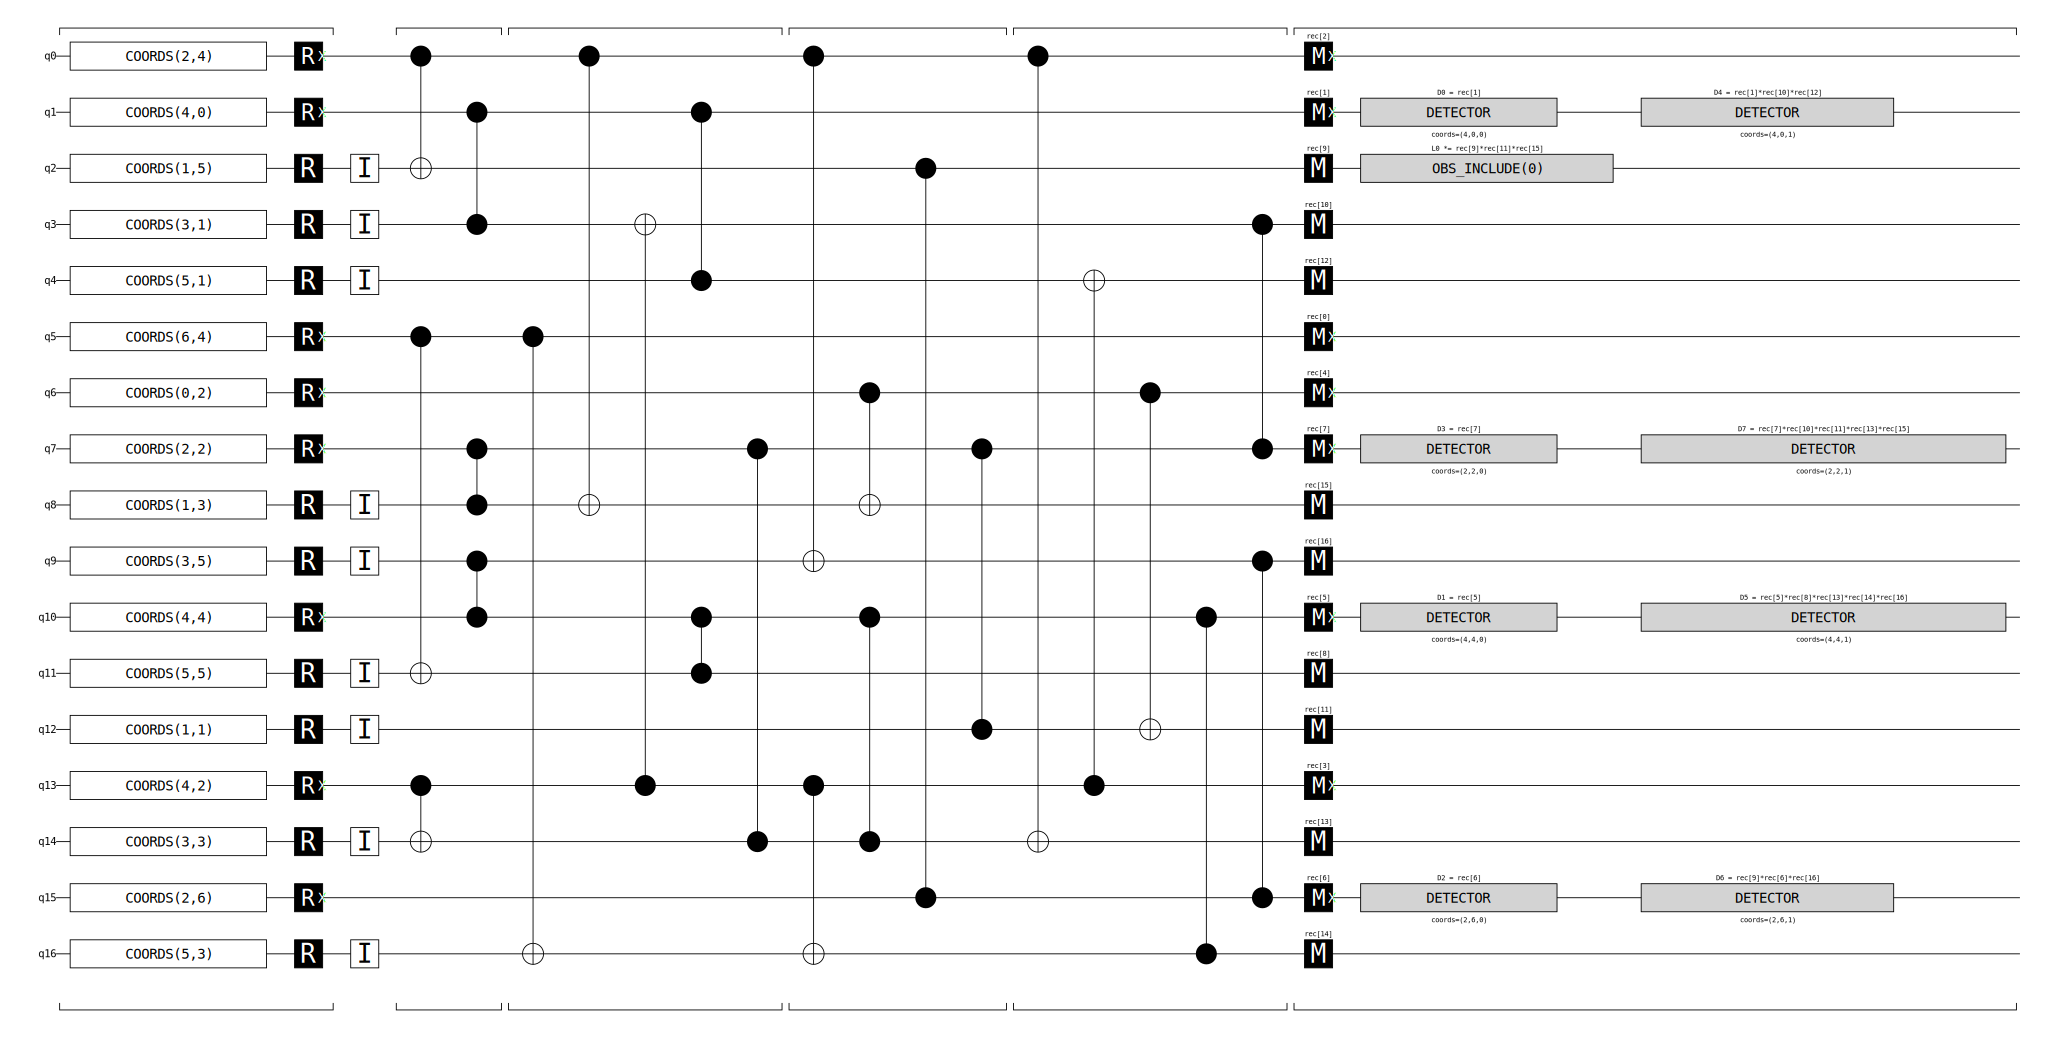

In [41]:
# a very helpful way to visualise circuits
circ_to_vis = stim.Circuit(textbook_circuit)
circ_to_vis.diagram(type="timeline-svg")

# an earlier version of this plot actually got me to learn that the 
# rotated codes use (d^2 +1)/ 2 qubits


In [42]:
#based on the gates in circuit, basis gates need to be specified
experiment_definition.basis_gates = ["CZ", "H", "MZ", "RZ"]
# you can't know the basis gates until you visualise the textbook circuit first

compiled_circuit = client.generate_circuit(experiment_definition)

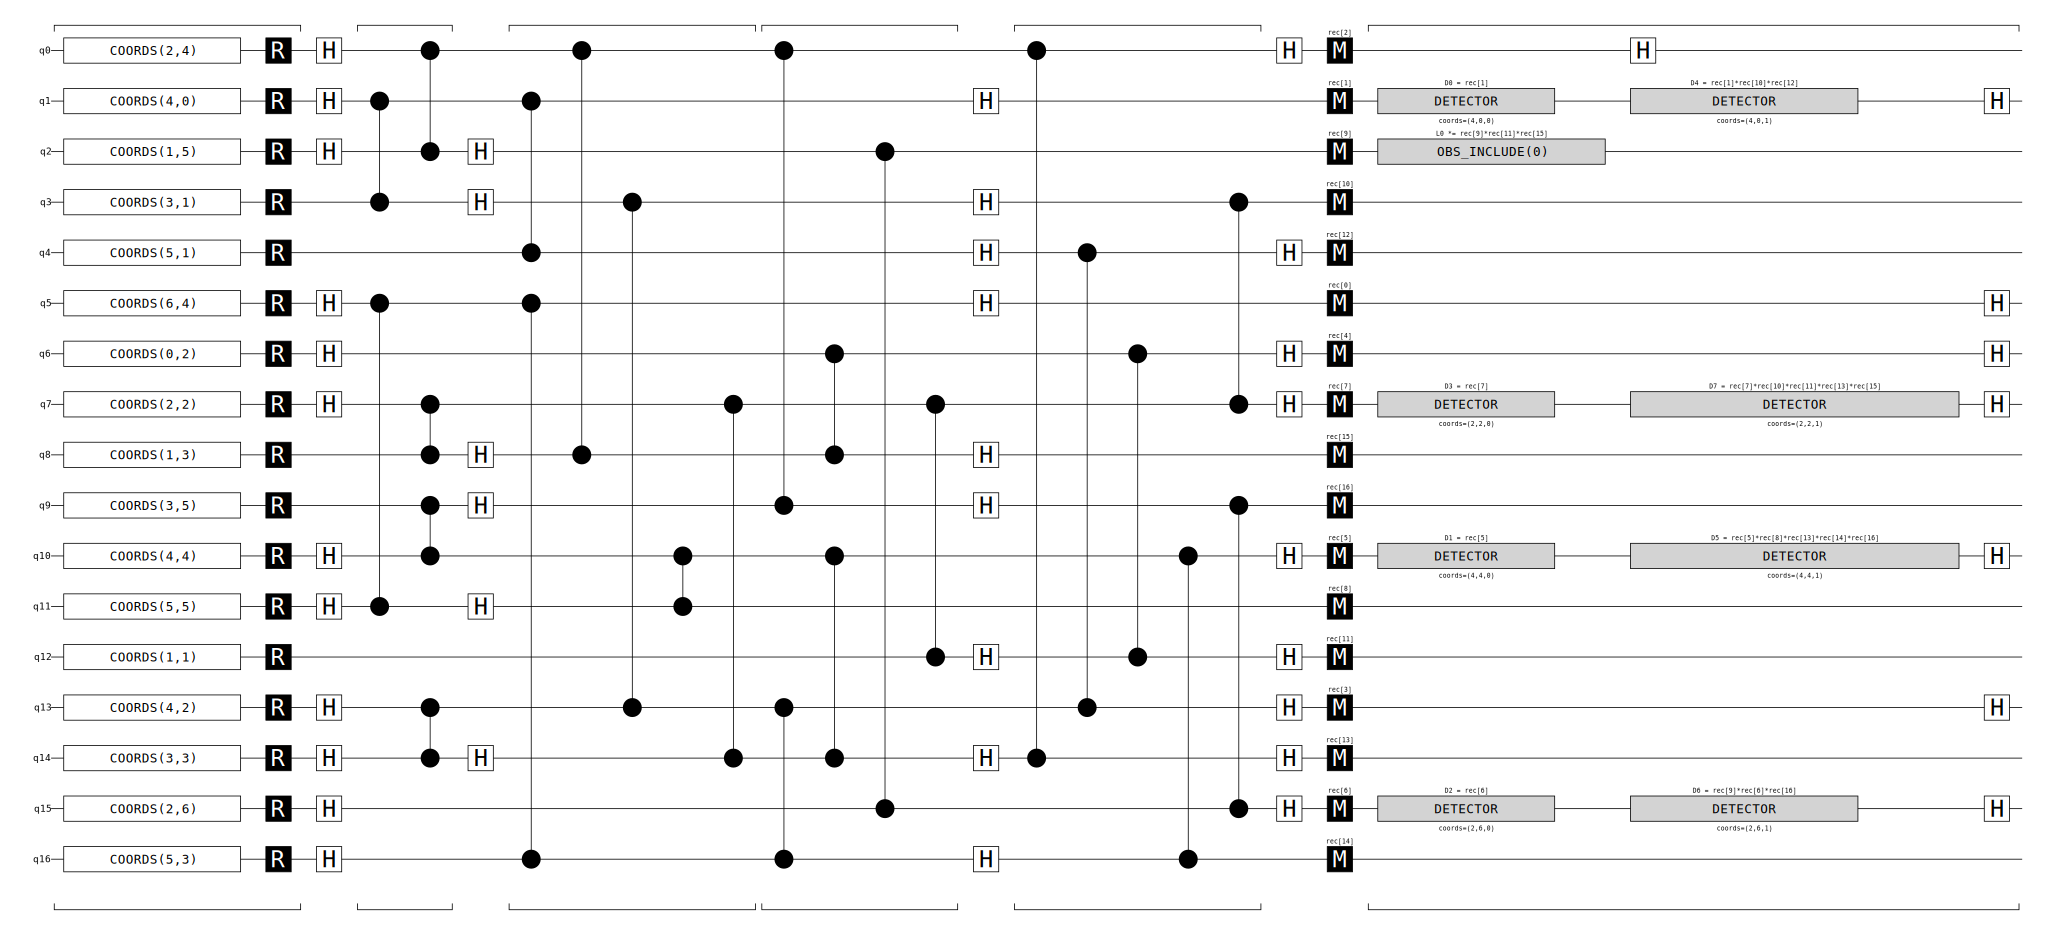

In [43]:
stim.Circuit(compiled_circuit).diagram(type="timeline-svg")

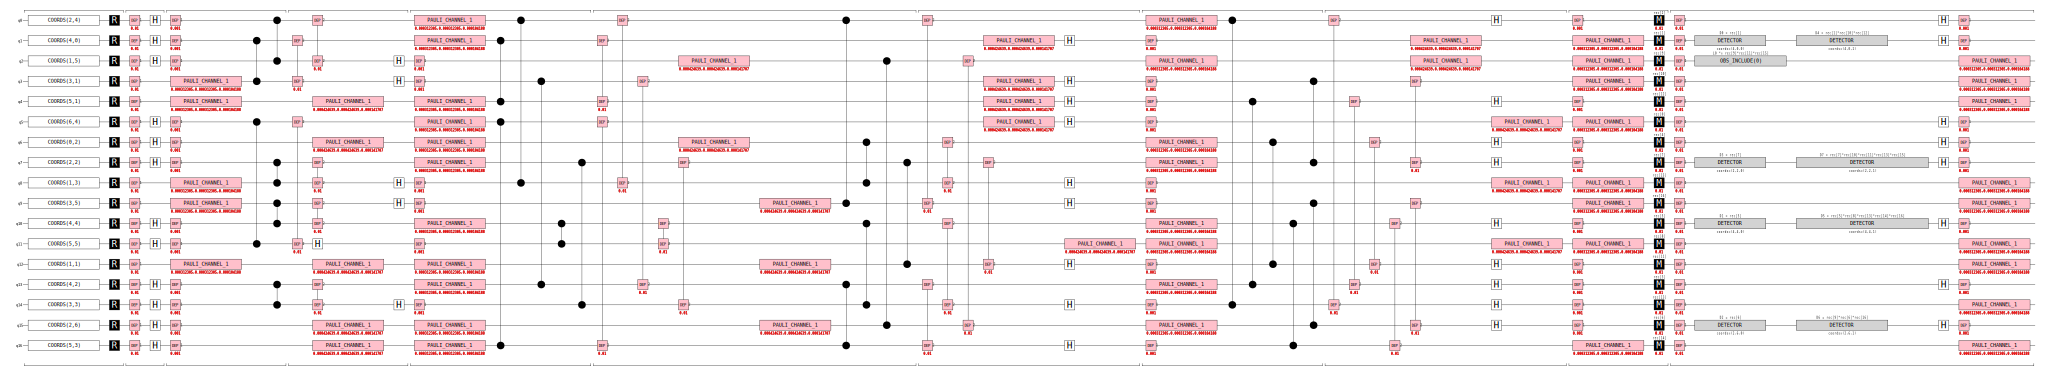

In [44]:
# now to add some ✨noise✨

# define the noise model you want
noise_model = PhysicalNoiseModel.get_superconducting_noise()

# now incorporate the noise
noisy_circuit = client.add_noise(
    stim_circuit= compiled_circuit,
    noise_model=noise_model,
)

# visualise the noisy circuit
stim.Circuit(noisy_circuit).diagram(type="timeline-svg")

## Simulate and Decode

In [45]:
# simulating shots
num_shots = 1000

measurements, _ = client.simulate_stim_circuit(
    stim_circuit=noisy_circuit,
    shots=num_shots,
)

In [46]:
# pick a decoder 
decoder = Decoder(DecoderType.MWPM)

# we need measurements and the decoder
# along with the noiseless circuit and the error model used

decoder_results = client.decode_measurements(
    measurements=measurements,
    decoder=decoder,
    ideal_stim_circuit=compiled_circuit,
    noise_model=noise_model
)


### Now we can try varying distance and the number of rounds

At the moment, this experiment is just a circuit that does 1 measurement round, 5000 times (number of shots). We do this to get our probabilities.

In reality though, multiple rounds of error detection are done *during* computation, and circuits aren't run reapetedly unless computation requires it (like in running Grover's algorithm). However, more measurements are an opportunity for read out errors.

As for varying the distance, it will take a larger number of physical errors for a logical error to occur, so the logical error rate is supressed.

#### Let's start with varying rounds

In [47]:
# We already set basis gates for the experiment definition
# so we can directly reuse it

# define a compiled circuit for each round
compiled_circuits = {}
all_rounds = [1, 3, 5, 7, 9]

for num_rounds in all_rounds:
    experiment_definition.num_rounds = num_rounds
    compiled_circuits[num_rounds] = client.generate_circuit(experiment_definition)
    

In [48]:
# now let's add some noise to each of our circuits
noisy_circuits = {}

for num_rounds, circuit in compiled_circuits.items():
    noisy_circuits[num_rounds] = client.add_noise(
        stim_circuit= circuit,
        noise_model=noise_model,
    )

In [49]:
# simulating and decoding

num_shots = 100_000
results = {}

for num_rounds in all_rounds:
    noisy_circuit = noisy_circuits[num_rounds]
    compiled_circuit = compiled_circuits[num_rounds]

    #simulate noisy circuit
    measurements, _ = client.simulate_stim_circuit(
        stim_circuit= noisy_circuit,
        shots = num_shots,
    )

    #decode
    decoder_result = client.decode_measurements(
        measurements=measurements,
        decoder=decoder,
        ideal_stim_circuit=compiled_circuit,
        noise_model=noise_model,
    )

    results[num_rounds] = decoder_results

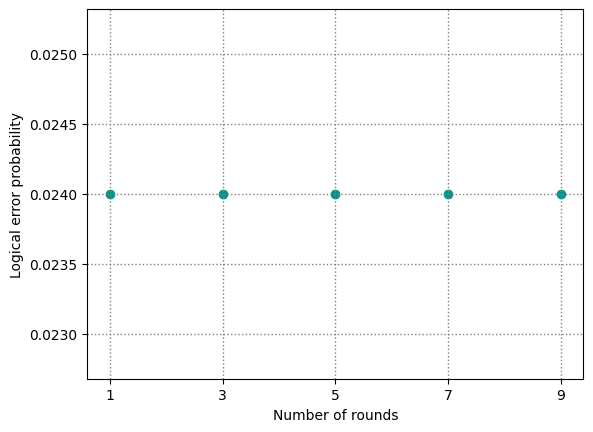

In [50]:
#time to visualise✨

logical_error_probs_d3 = [results[num_rounds].get_logical_error_probability() for num_rounds in all_rounds]
plt.scatter(all_rounds, logical_error_probs_d3, color="#00968f")

plt.grid(color="gray", linestyle=":", linewidth=1)
plt.xticks(all_rounds)
plt.xlabel("Number of rounds")
plt.ylabel("Logical error probability")
plt.show()

### Now let's vary the distances

In [51]:
logical_error_probs_d5 = []

# this sets the distance for our experiment definition to 5
experiment_definition.parameters = CircuitParameters(sizes=Sizes([5]))

for num_rounds in all_rounds:

    # need these for simulation and decoding
    noisy_circuit = noisy_circuits[num_rounds]
    compiled_circuit = compiled_circuits[num_rounds]

    #simulate noisy circuit
    measurements, _ = client.simulate_stim_circuit(
        stim_circuit= noisy_circuit,
        shots = num_shots,
    )

    #decode
    decoder_result = client.decode_measurements(
        measurements=measurements,
        decoder=decoder,
        ideal_stim_circuit=compiled_circuit,
        noise_model=noise_model,
    )

    logical_error_probs_d5.append(decoder_result.get_logical_error_probability())


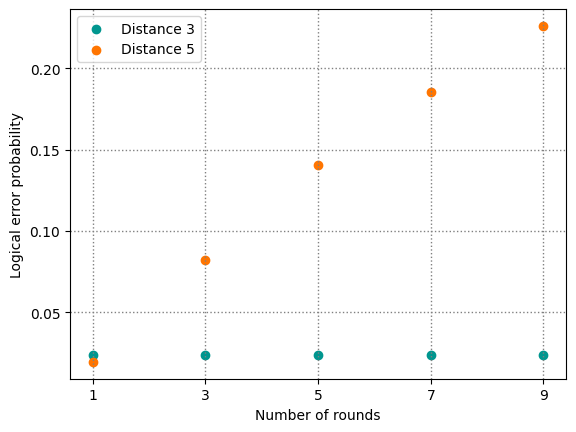

In [52]:
plt.scatter(all_rounds, logical_error_probs_d3, color="#00968f", label="Distance 3")
plt.scatter(all_rounds, logical_error_probs_d5, color="#ff7500", label="Distance 5")

plt.grid(color="gray", linestyle=":", linewidth=1)
plt.xticks(all_rounds)
plt.xlabel("Number of rounds")
plt.ylabel("Logical error probability")
plt.legend()
plt.show()